In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

In [5]:
df = pd.read_csv('/content/books KNN Algorithm.csv', on_bad_lines='skip')

In [6]:
df.columns = df.columns.str.strip()

In [8]:
features = df [['average_rating', 'num_pages', 'ratings_count']]

In [9]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

In [10]:
model = NearestNeighbors(n_neighbors=6, algorithm='brute', metric='cosine')
model.fit(scaled_features)

NearestNeighbors(algorithm='brute', metric='cosine', n_neighbors=6)

<function matplotlib.pyplot.show(close=None, block=None)>

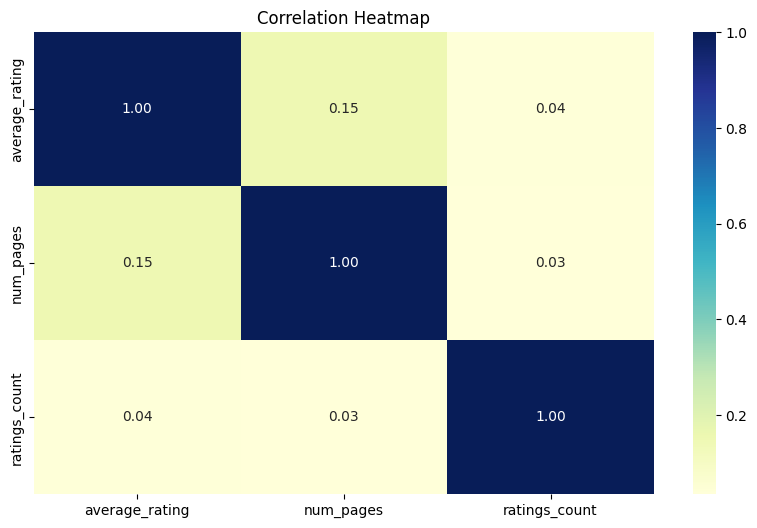

In [11]:
plt.figure(figsize=(10, 6))
sns.heatmap(features.corr(), annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show

In [13]:
def get_recommendations(book_index):
  distances, indices = model.kneighbors(scaled_features[book_index].reshape(1, -1))
  print(f"If you liked: {df.iloc[book_index]['title']}")
  print("You might also like:")
  for i in range(1, len(indices[0])):
    print(f"- {df.iloc[indices[0][i]]['title']}")

get_recommendations(0)

If you liked: Harry Potter and the Half-Blood Prince (Harry Potter  #6)
You might also like:
- The Book Thief
- Where the Heart Is
- Heidi (Heidi  #1-2)
- The Pelican Brief
- The 7 Habits of Highly Effective People: Powerful Lessons in Personal Change
